**Initial Setup & Data Loading**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Instagram_Analytics.csv')
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


**Basic Info**

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

In [30]:
df.shape

(29999, 23)

In [31]:
df.columns

Index(['post_id', 'account_id', 'account_type', 'follower_count', 'media_type',
       'content_category', 'traffic_source', 'has_call_to_action',
       'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes',
       'comments', 'shares', 'saves', 'reach', 'impressions',
       'engagement_rate', 'followers_gained', 'caption_length',
       'hashtags_count', 'performance_bucket_label'],
      dtype='object')

**Data Understanding**

In [32]:
df.describe()

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


**Missing Values**

In [33]:
df.isnull().sum()

,0
post_id,0
account_id,0
account_type,0
follower_count,0
media_type,0
content_category,0
traffic_source,0
has_call_to_action,0
post_datetime,0
post_date,0


**Duplicate Check**

In [34]:
df.duplicated().sum()
df=df.drop_duplicates()

**Bivariate Analysis**

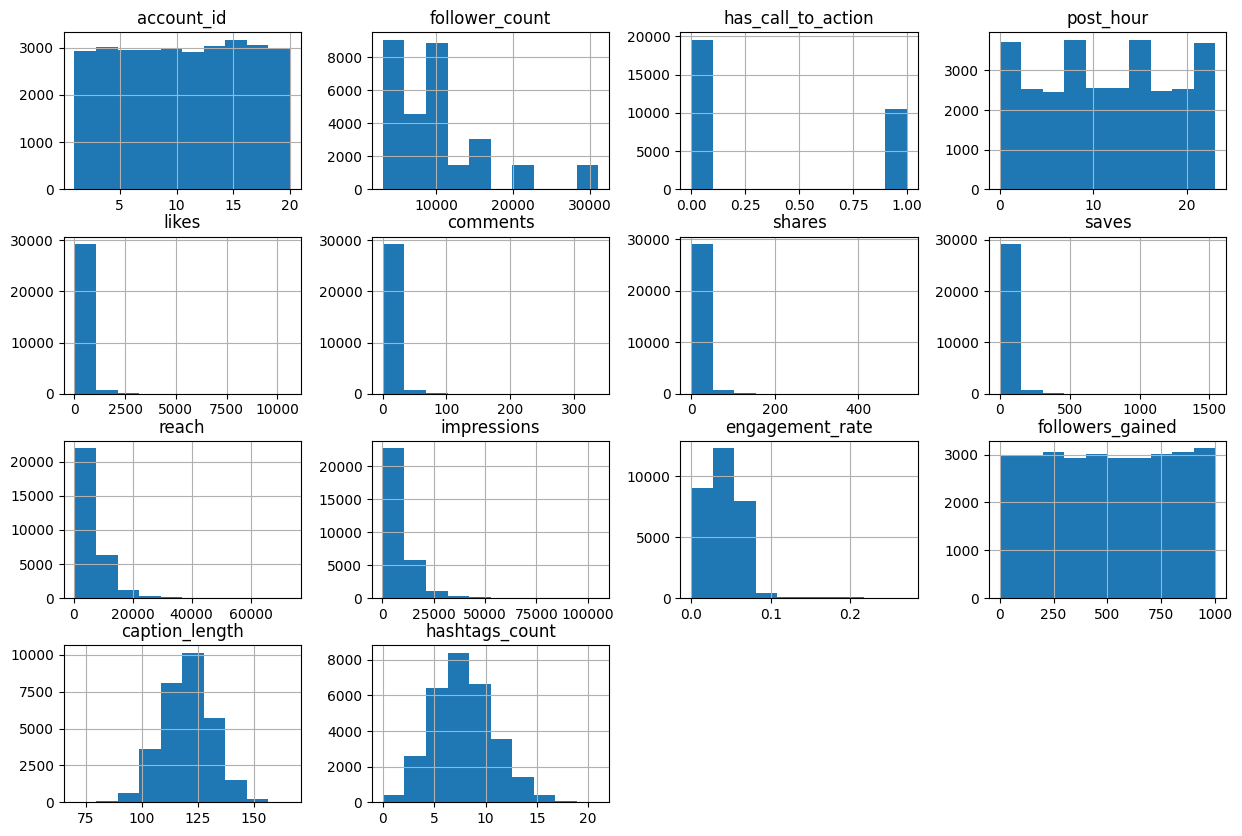

In [35]:
df.hist(figsize=(15,10))
plt.show()

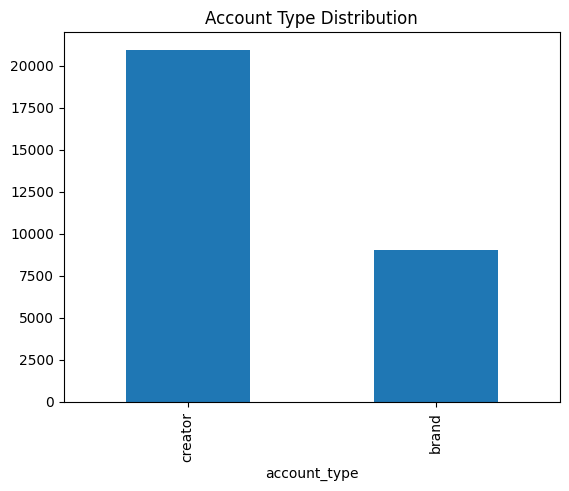

In [36]:
df['account_type'].value_counts().plot(kind='bar')
plt.title("Account Type Distribution")
plt.show()

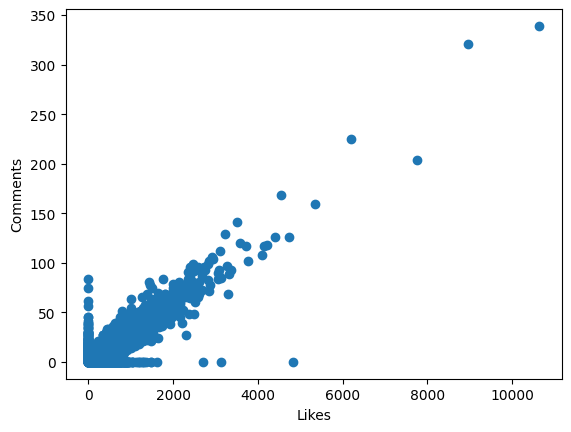

In [37]:
plt.scatter(df['likes'], df['comments'])
plt.xlabel("Likes")
plt.ylabel("Comments")
plt.show()

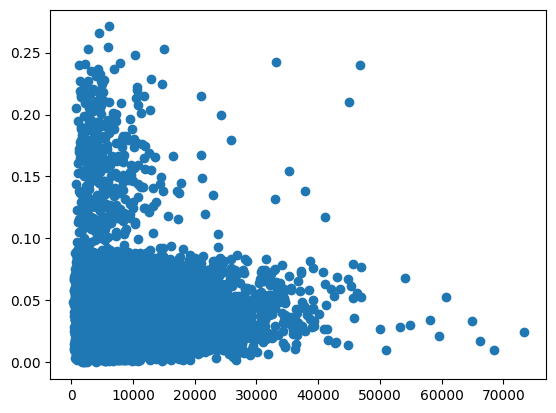

In [38]:
plt.scatter(df['reach'], df['engagement_rate'])
plt.show()

time_category
After 7 PM     8486.066409
Before 7 PM    8461.953785
Name: impressions, dtype: float64


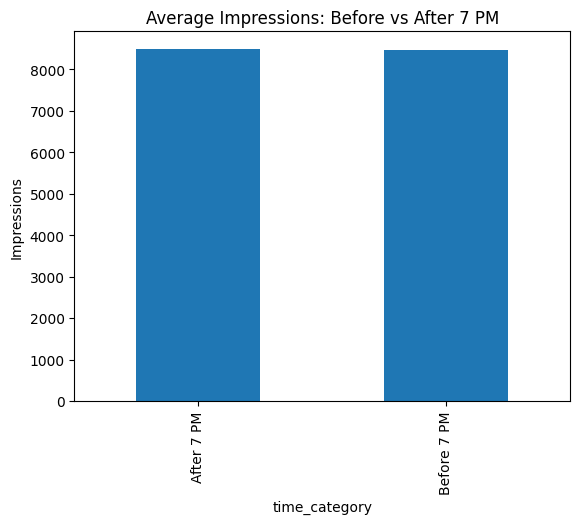

In [39]:
df['time_category'] = df['post_hour'].apply(lambda x: 'After 7 PM' if x >= 19 else 'Before 7 PM')

time_analysis = df.groupby('time_category')['impressions'].mean()
print(time_analysis)

time_analysis.plot(kind='bar')
plt.title("Average Impressions: Before vs After 7 PM")
plt.ylabel("Impressions")
plt.show()

**Feature Engineering**

In [40]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares'] + df['saves']

df['high_engagement'] = df['engagement_rate'] > df['engagement_rate'].mean()
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label,time_category,engagement_score,high_engagement
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,4327,6230,0.0385,899,100,7,medium,Before 7 PM,240,False
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,7451,8268,0.0663,805,122,5,viral,Before 7 PM,548,True
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,1639,2616,0.0531,758,115,8,high,Before 7 PM,139,True
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,2877,3171,0.0309,402,115,7,medium,Before 7 PM,98,False
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,5350,8503,0.0221,155,112,9,low,Before 7 PM,188,False


**Outliers Detection**

In [41]:
Q1 = df['likes'].quantile(0.25)
Q3 = df['likes'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['likes'] >= Q1 - 1.5*IQR) & (df['likes'] <= Q3 + 1.5*IQR)]

In [42]:
from scipy.stats import zscore

df = df[(np.abs(zscore(df['likes'])) < 3)]

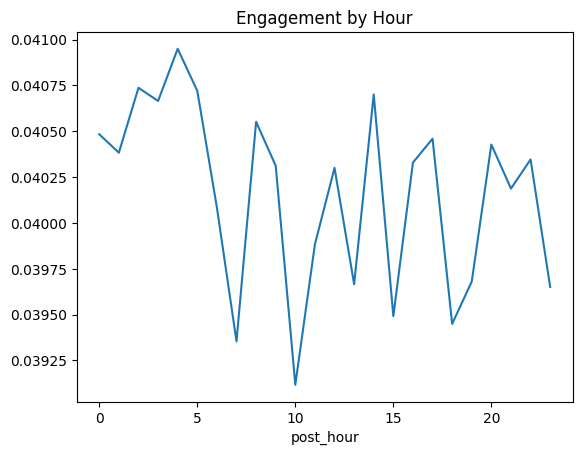

In [43]:
df.groupby('post_hour')['engagement_rate'].mean().plot()
plt.title("Engagement by Hour")
plt.show()

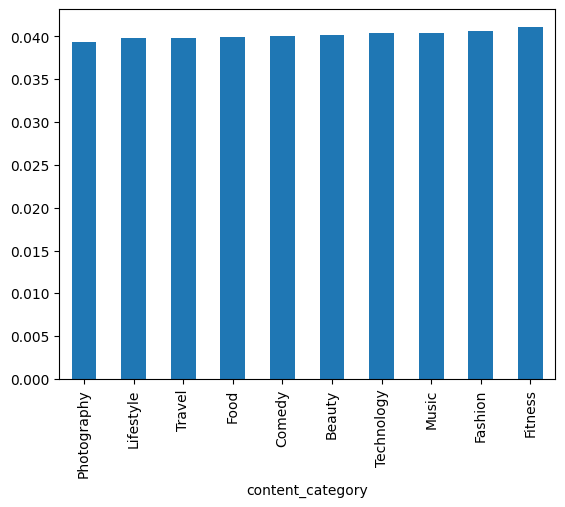

In [44]:
df.groupby('content_category')['engagement_rate'].mean().sort_values().plot(kind='bar')
plt.show()

In [47]:
# For Understanding
df['performance_bucket_label'] = df['performance_bucket_label'].replace({
    'low': 'Low Engagement',
    'medium': 'Average Engagement',
    'high': 'High Engagement',
    'viral': 'Viral (Top Posts)'
})

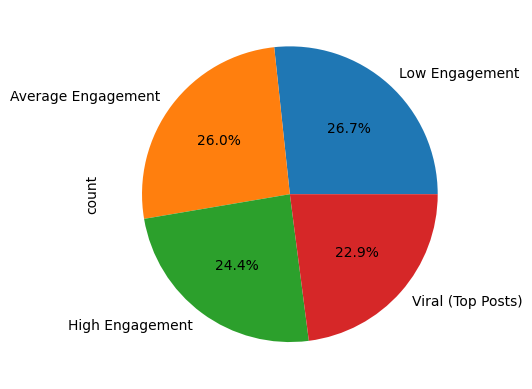

In [48]:
df['performance_bucket_label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()